In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import emoji
import unicodedata
import nltk
import spacy
from spacy import displacy
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Emoji handling
import emoji

# Spell correction and contractions
from textblob import TextBlob
import contractions
from langdetect import detect, LangDetectException

# Multiprocessing and progress bars
from multiprocessing import Pool, cpu_count
from functools import lru_cache, partial
from tqdm import tqdm

# ML and encoding
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# Deep learning tools
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Word embeddings
from gensim.models import Word2Vec

In [3]:
# Setup NLP resources
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
spacy_nlp = spacy.load("en_core_web_sm")
lemmatizer = WordNetLemmatizer()

In [5]:
# Load spaCy model for NER
import en_core_web_sm
nlp_spacy = en_core_web_sm.load()

# Disable unnecessary components for faster NER
nlp_spacy.disable_pipes("tagger", "parser", "lemmatizer")

['tagger', 'parser', 'lemmatizer']

In [7]:
# Load Data
corpus_df = pd.read_csv("C:/Users/Mansi/Downloads/Sentiment_Data/Sentiment_Data.csv", encoding="ISO-8859-1")

In [9]:
# Check the head of the dataframe
corpus_df.head()

,Tweet,Sentiment
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos


In [11]:
# Show data overview
print("Dataset Overview:")
print(f"Dataset shape: {corpus_df.shape}")
print(f"Columns: {corpus_df.columns.tolist()}")
print("\nSentiment Distribution:")
print(corpus_df['Sentiment'].value_counts())

Dataset Overview:
Dataset shape: (451332, 2)
Columns: ['Tweet', 'Sentiment']

Sentiment Distribution:
Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


In [13]:
# Create abbreviation dictionary
slang_dict = {
    "u": "you",
    "ur": "your",
    "n": "and",
    "2": "to",
    "4": "for",
    "w/": "with",
    "w/o": "without",
    "thru": "through",
    "tho": "though",
    "gonna": "going to",
    "wanna": "want to",
    "gotta": "got to",
    "kinda": "kind of",
    "sorta": "sort of",
    "outta": "out of",
    "dunno": "don't know",
    "gimme": "give me",
    "lemme": "let me",
    "btw": "by the way",
    "omg": "oh my god",
    "lol": "laugh out loud",
    "rofl": "rolling on floor laughing",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "aka": "also known as",
    "asap": "as soon as possible",
    "fyi": "for your information",
    "diy": "do it yourself",
    "faq": "frequently asked questions",
    "irl": "in real life",
    "ppl": "people",
    "msg": "message",
    "txt": "text",
    "pic": "picture",
    "vid": "video",
    "app": "application",
    "tech": "technology",
    "biz": "business",
    "edu": "education",
    "gov": "government",
    "org": "organization",
    "info": "information",
    "omg": "oh my god",
    "lol": "laugh out loud",
    "btw": "by the way",
    "idk": "i do not know",
    "smh": "shaking my head",
    "afaik": "as far as i know",
    "tbh": "to be honest",
    "imo": "in my opinion",
    "icymi": "in case you missed it",
    "fwiw": "for what it is worth",
    "ftw": "for the win",
    "lmk": "let me know",
    "rn": "right now",
    "thx": "thanks",
    "til": "today i learned",
    "brb": "be right back",
    "gg": "good game",
    "noob": "newbie",
    "ootd": "outfit of the day",
    "fyp": "for you page",
    "hmu": "hit me up",
    "iiuc": "if i understand correctly",
    "ikr": "i know, right",
    "irl": "in real life",
    "iss": "i am so sorry",
    "jsyk": "just so you know",
    "lowkey": "quietly",
    "highkey": "obviously",
    "ngl": "not gonna lie",
    "oot": "out of the",
    "pls": "please",
    "rizz": "charisma",
    "ship": "support a romantic relationship",
    "slay": "do something well",
    "s/o": "shoutout",
    "stan": "support",
    "tbf": "to be fair",
    "tea": "gossip",
    "vibe check": "evaluation of mood",
    "wtf": "what the freak",
    "wym": "what you mean",
    "yaaas": "strong agreement",
    "cc": "carbon-copy",
    "cx": "correction",
    "ct": "cut tweet",
    "dm": "direct message",
    "ht": "hat tip",
    "mt": "modified tweet",
    "prt": "please retweet",
    "rt": "retweet",
    "em": "email marketing",
    "ezine": "electronic magazine",
    "fb": "facebook",
    "li": "linkedin",
    "seo": "search engine optimization",
    "sm": "social media",
    "smm": "social media marketing",
    "smo": "social media optimization",
    "sn": "social network",
    "sroi": "social return on investment",
    "ugc": "user generated content",
    "yt": "youtube",
    "ab/abt": "about",
    "b4": "before",
    "bfn": "bye for now",
    "bgd": "background",
    "bh": "blockhead",
    "br": "best regards",
    "cd9": "code 9",
    "chk": "check",
    "cul8r": "see you later",
    "dam": "don not annoy me",
    "dd": "dear daughter",
    "df": "dear fiancé",
    "dp": "profile pic",
    "ds": "dear son",
    "dyk": "did you know, do you know",
    "ema": "email address",
    "ftf": "face to face",
    "f2f": "face to face",
    "ff": "follow friday",
    "fotd": "find of the day",
    "gts": "guess the song",
    "hagn": "have a good night",
    "hand": "have a nice day",
    "hotd": "headline of the day",
    "hth": "hope that helps",
    "ic": "i see",
    "iirc": "if i remember correctly",
    "jk": "just kidding, joke",
    "jv": "joint venture",
    "kk": "ok got it",
    "kyso": "knock your socks off",
    "lhh": "laugh hella hard",
    "lmao": "laughing my ass off",
    "lo": "little one",
    "mm": "music monday",
    "mirl": "meet in real life",
    "nbd": "no big deal",
    "nct": "nobody cares, though",
    "nfw": "no freaking way",
    "njoy": "enjoy",
    "nsfw": "not safe for work",
    "nts": "note to self",
    "oh": "overheard",
    "omfg": "oh my freaking god",
    "oomf": "one of my followers",
    "orly": "oh really",
    "plmk": "please let me know",
    "pnp": "party and play",
    "qotd": "quote of the day",
    "re": "in reply to, in regards to",
    "rlrt": "real-life re-tweet",
    "rtq": "read the question",
    "sfw": "safe for work",
    "smdh": "shaking my damn head",
    "so": "significant other",
    "srs": "serious",
    "tftf": "thanks for the follow",
    "tf": "thanks for this tweet",
    "tj": "tweetjack",
    "tl": "timeline",
    "tldr": "too long, did not read",
    "tmb": "tweet me back",
    "tt": "trending topic",
    "tyia": "thank you in advance",
    "tyt": "take your time",
    "tyvw": "thank you very much",
    "w/": "with",
    "w/e": "weekend",
    "wtv": "whatever",
    "ygtr": "you got that right",
    "ykwim": "you know what i mean",
    "ykyat": "you know you are addicted to",
    "ymmv": "your mileage may vary",
    "yolo": "you only live once",
    "yoyo": "you are on your own",
    "yw": "you are welcome",
    "zomg": "omg to the max"
}
lemmatizer = WordNetLemmatizer()

### Text Cleaning Functions

In [15]:
# Function to clean dataset
def process_emojis_symbols(text):
    if not isinstance(text, str):
        return ""
    # Process emojis
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Remove non-grammatical symbols
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)  # URLs
    text = re.sub(r'@\w+', ' ', text)                   # Mentions
    text = re.sub(r'#(\w+)', r'\1', text)               # hashtags keep text
    text = re.sub(r'[^a-zA-Z0-9\s\-]', ' ', text)       # non-alphanum except hyphens

    # Expand contractions
    text = contractions.fix(text)

    return text

# Named Entity Recognition Processing
def extract_entities(text):
    return " ".join([ent.text for ent in nlp_spacy(text).ents]) or text

# Spelling corrections
def correct_spelling(text):
    return str(TextBlob(text).correct()) if isinstance(text, str) else ""

# Slang and Abbreviation handler
def expand_slangs(text):
    return ' '.join([slang_dict.get(word, word) for word in text.split()])

# Non-grammatical punctuation removal
def remove_punctuations(text):
    text = re.sub(r'[^\w\s-]', ' ', text)  # Keep hyphens
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Helper to convert nltk POS tags to wordnet tags
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # Default to noun

import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])  # Save memory

def lemmatize_texts_spacy(texts, batch_size=1000):
    for doc in nlp.pipe(texts, batch_size=batch_size):
        yield " ".join([
            token.text if token.text.startswith('#') or token.text.startswith('@') or token.text.isupper()
            else token.lemma_.lower()
            for token in doc if not (token.is_punct or token.is_space)
        ])

def is_english(text):
    try:
        return detect(text) == "en"
    except LangDetectException:
        return False


### Complete Pipeline

In [17]:
def clean_pipeline(text):
    text = process_emojis_symbols(text)
    # text = extract_entities(text) Skipped due to excessive computational requirements
    text = text.lower()
    # text = correct_spelling(text) Skipped due to excessive computational requirements
    text = expand_slangs(text)
    text = remove_punctuations(text)
    return text

In [19]:
corpus_df['Tweet'] = corpus_df['Tweet'].fillna("")

In [21]:
# Processing the pipeline
tqdm.pandas()
corpus_df['Cleaned_Text'] = corpus_df['Tweet'].progress_apply(clean_pipeline)

100%|████████████████████████████████████████████████████████████████████████| 451332/451332 [01:49<00:00, 4124.23it/s]


In [23]:
# Lemmatize in batch
corpus_df['Cleaned_Text'] = list(lemmatize_texts_spacy(corpus_df['Cleaned_Text']))

# Filter to English only
corpus_df = corpus_df[corpus_df['Cleaned_Text'].apply(is_english)].reset_index(drop=True)


In [25]:
# Check the new dataframe
corpus_df.head()

,Tweet,Sentiment,Cleaned_Text
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos,happy anniversary the day the freedumb die in ...
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos,happy anniversary the day the freedumb die in ...
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos,happy anniversary the day the freedumb die in ...
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos,happy anniversary the day the freedumb die in ...
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos,happy anniversary the day the freedumb die in ...


In [27]:
corpus_df['Cleaned_Text'].tail(20)


429495    watch zuma and banda at freedom statue listeni...
429496    the red gossip party express bus be the ronald...
429497    gossip party express on the road again pull in...
429498    retweet direction and parking information for ...
429499    teaparty express be also know as wheel for fre...
429500    gossip party express wheel of freedom be take ...
429501    retweet teaparty express arrive in albuquerque...
429502    teaparty express just arrive in albuquerque to...
429503    security convoy on way to pick up convict lock...
429504    new blog post freedom convoy tour the okanagan...
429505    new blog post freedom convoy regional schedule...
429506    new blog post freedom route convoy will stop i...
429507    freedom convoy make city stop the army navy ai...
429508    next week freedom snatch go for 44- tie convoy...
429509    broll of a navy convoy cross the kuwaiti iraqi...
429510    watch broll of a navy convoy cross the kuwaiti...
429511    gaza peace and freedom viva pa

In [29]:
#Sanity Check to see if Lemmetization worked well

In [31]:
samples = corpus_df.sample(5)
for i, row in samples.iterrows():
    print("Original:", row["Tweet"])
    print("Cleaned:", clean_pipeline(row["Tweet"]))
    print("-" * 40)

Original: Capitol fencing reinstalled ahead of State of the Union, âFreedom ConvoyâÂ spinoffs https://t.co/4r5DX0shei
Cleaned: capitol fencing reinstalled ahead of state of the union afreedom convoyaa spinoffs
----------------------------------------
Original: Support #FreedomConvoy  this is tyranny!
Cleaned: support freedomconvoy this is tyranny
----------------------------------------
Original: #Guelph Ontario 1 year ago today #FreedomConvoy https://t.co/aKLZKSoZxU
Cleaned: guelph ontario 1 year ago today freedomconvoy
----------------------------------------
Original: Donation site for Ottawa truckersâ â#FreedomConvoyâ protest exposed donorsâ data â TechCrunch https://t.co/KxJNOERr9n
Cleaned: donation site for ottawa truckersa afreedomconvoya protest exposed donorsa data a techcrunch
----------------------------------------
Original: the same people speaking out about Police Violence during Black Lives Matter protests are now cheering on Police Violence at Freedom Conv

In [33]:
corpus_df.to_csv('corpus_df_full.csv', index=False)


### Check the Data Quality

In [35]:
# Data Quality Report
print("\n=== Data Quality Report ===")
print(f"Total samples: {len(corpus_df):,}")
print(f"Missing values: {corpus_df['Cleaned_Text'].isnull().sum():,}")
print(f"Empty strings after cleaning: {corpus_df['Cleaned_Text'].eq('').sum():,}")


=== Data Quality Report ===
Total samples: 429,515
Missing values: 0
Empty strings after cleaning: 0


In [37]:
# Remove empty texts
corpus_df = corpus_df[corpus_df['Cleaned_Text'].str.strip().astype(bool)]

### Consolidate Sentiments

In [39]:
# Merge sentiment categories
def merge_sentiments(sentiment):
    if sentiment in ['Mild_Pos', 'Strong_Pos']:
        return 'Positive'
    elif sentiment in ['Mild_Neg', 'Strong_Neg']:
        return 'Negative'
    else:
        return 'Neutral'

corpus_df['Sentiment_Merged'] = corpus_df['Sentiment'].apply(merge_sentiments)
print("\nMerged Sentiment Distribution:")
print(corpus_df['Sentiment_Merged'].value_counts())


Merged Sentiment Distribution:
Sentiment_Merged
Positive    285605
Negative     75154
Neutral      68756
Name: count, dtype: int64


In [41]:
# Balance dataset
sample_size = 30000
print(f"Balancing dataset with {sample_size} samples per class.")

def balance_dataset(df, target_col='Sentiment_Merged', min_count=None):
    if min_count is None:
        min_count = df[target_col].value_counts().min()

    balanced_dfs = []
    for sentiment in df[target_col].unique():
        sentiment_df = df[df[target_col] == sentiment]
        if len(sentiment_df) > min_count:
            balanced_df = sentiment_df.sample(n=min_count, random_state=42)
        else:
            balanced_df = sentiment_df
        balanced_dfs.append(balanced_df)

    return pd.concat(balanced_dfs, ignore_index=True)

balanced_corpus = balance_dataset(corpus_df, min_count=sample_size)
print(f"Balanced dataset shape: {balanced_corpus.shape}")

Balancing dataset with 30000 samples per class.
Balanced dataset shape: (90000, 4)


In [43]:
corpus_df = balance_dataset(corpus_df, min_count=sample_size)
print(f"Balanced dataset shape: {balanced_corpus.shape}")
print("Balanced sentiment distribution:")
print(corpus_df['Sentiment_Merged'].value_counts())

Balanced dataset shape: (90000, 4)
Balanced sentiment distribution:
Sentiment_Merged
Positive    30000
Neutral     30000
Negative    30000
Name: count, dtype: int64


### Class Separability Analysis

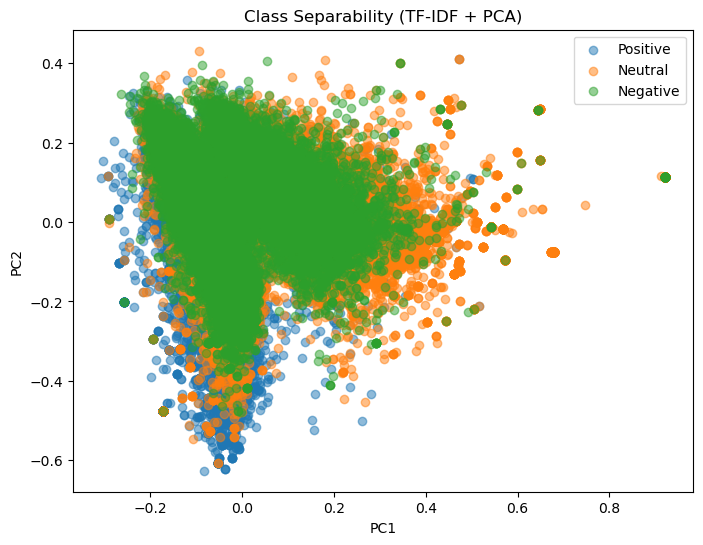

In [45]:
# Class Separability Analysis (using TF-IDF and PCA)
tf_vectorizer = TfidfVectorizer(max_features=500)
X = tf_vectorizer.fit_transform(corpus_df['Cleaned_Text'].fillna(''))

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
for sentiment in corpus_df['Sentiment_Merged'].unique():
    idx = corpus_df['Sentiment_Merged'] == sentiment
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=sentiment, alpha=0.5)
plt.title('Class Separability (TF-IDF + PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

### Prepare encodings and Train-Test Splits for Models

In [47]:
# LSTM/Transformers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(corpus_df['Sentiment_Merged'])

vocab_size = 10000
max_len = 250

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(corpus_df['Cleaned_Text'])
sequences = tokenizer.texts_to_sequences(corpus_df['Cleaned_Text'])
pad_sequences_data = pad_sequences(sequences, maxlen=max_len, truncating='post')

X_train, X_test, y_train, y_test = train_test_split(
    pad_sequences_data, y, test_size=0.2, random_state=42, stratify=y)

In [49]:
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

# Tokenize cleaned text
corpus_df["Tokenized_Tweet"] = corpus_df["Cleaned_Text"].apply(lambda x: word_tokenize(x))

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=corpus_df["Tokenized_Tweet"],
    vector_size=100, window=5, min_count=2, sg=1, workers=4
)

# Function to create average vector
def tweet_to_vec(tweet, model, target_size=100):
    vectors = [model.wv[word] for word in tweet if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(target_size)

corpus_df["Tweet_Vector"] = corpus_df["Tokenized_Tweet"].apply(lambda x: tweet_to_vec(x, w2v_model))
X_word2vec = np.vstack(corpus_df["Tweet_Vector"].values)

# Split for Word2Vec data
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_word2vec, y, test_size=0.2, random_state=42, stratify=y)

### Compute Class Weights

In [51]:
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

### Save Processed Datasets & Processing Tools

In [53]:
import pickle
import os
save_dir = "./processed_data/"
os.makedirs(save_dir, exist_ok=True)

# Sequence data for LSTM/Transformers
np.save(f"{save_dir}X_train.npy", X_train)
np.save(f"{save_dir}X_test.npy", X_test)

# Word2Vec average vectors
np.save(f"{save_dir}X_train_word2vec.npy", X_train_w2v)
np.save(f"{save_dir}X_test_word2vec.npy", X_test_w2v)

# Labels (same across both)
np.save(f"{save_dir}y_train.npy", y_train)
np.save(f"{save_dir}y_test.npy", y_test)

# Save tokenizer and encoders
with open(f"{save_dir}tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
with open(f"{save_dir}label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
with open(f"{save_dir}class_weights.pkl", "wb") as f:
    pickle.dump(class_weight_dict, f)

# Save cleaned dataframe
corpus_df.to_csv(f"{save_dir}Cleaned_Dataset.csv", index=False)

### BiLSTM with Learnable Embedding

In [55]:
import numpy as np
import pickle

# Load data arrays
X_train_seq = np.load("C:/Users/Mansi/Downloads/X_train.npy", allow_pickle=True)
X_test_seq = np.load("C:/Users/Mansi/Downloads/X_test.npy", allow_pickle=True)
y_train = np.load("C:/Users/Mansi/Downloads/y_train.npy", allow_pickle=True)
y_test = np.load("C:/Users/Mansi/Downloads/y_test.npy", allow_pickle=True)

# Load tokenizer
with open("C:/Users/Mansi/Downloads/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

print("Data and tokenizer loaded")

Data and tokenizer loaded


In [57]:
# Define parameters from tokenizer and sequence data
MAX_VOCAB = len(tokenizer.word_index) + 1  # +1 for OOV token
MAX_LEN = X_train_seq.shape[1]  # Sequence length already padded

print(f"MAX_VOCAB = {MAX_VOCAB}, MAX_LEN = {MAX_LEN}")

MAX_VOCAB = 46930, MAX_LEN = 250


In [59]:
from tensorflow.keras.utils import to_categorical

# Convert integer labels (0/1/2) to one-hot vectors
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

print("Labels one-hot encoded")

Labels one-hot encoded


In [61]:
#Build the BiLSTM Model with Learnable Embedding

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

EMBED_DIM = 100

model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_shape=(MAX_LEN,)),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 250, 100)            │       4,693,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 128)                 │          84,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,781,707 (18.24 MB)

 Trainable params: 4,781,707 (18.24 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
#Train the Model

import time
start = time.time()

history = model.fit(
    X_train_seq, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

end = time.time()
print(f"Training completed in {end - start:.2f} seconds")


Epoch 1/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 164s 179ms/step - accuracy: 0.6100 - loss: 0.8291 - val_accuracy: 0.7454 - val_loss: 0.5984
Epoch 2/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 167s 186ms/step - accuracy: 0.7809 - loss: 0.5290 - val_accuracy: 0.7715 - val_loss: 0.5560
Epoch 3/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 161s 179ms/step - accuracy: 0.8253 - loss: 0.4332 - val_accuracy: 0.7849 - val_loss: 0.5392
Epoch 4/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 181s 201ms/step - accuracy: 0.8557 - loss: 0.3633 - val_accuracy: 0.7801 - val_loss: 0.5722
Epoch 5/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 173s 192ms/step - accuracy: 0.8804 - loss: 0.3070 - val_accuracy: 0.7812 - val_loss: 0.5842
Epoch 6/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 184s 204ms/step - accuracy: 0.8975 - loss: 0.2682 - val_accuracy: 0.7831 - val_loss: 0.6520
Epoch 7/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 222s 226ms/step - accuracy: 0.9119 - loss: 0.2358 - val_accuracy: 0.7738 - val_loss: 0.7542
Epoch 8/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 293s 260ms/step - accuracy: 0.9264 -

In [65]:
import numpy as np

# Predict class probabilities and final class labels
y_pred_probs = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

563/563 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step


In [67]:
# TASK: Compute F1 Score for Positive, Neutral, and Negative

from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Negative", "Neutral", "Positive"]))


Classification Report:

              precision    recall  f1-score   support

    Negative       0.79      0.80      0.80      6000
     Neutral       0.72      0.72      0.72      6000
    Positive       0.84      0.83      0.83      6000

    accuracy                           0.79     18000
   macro avg       0.79      0.79      0.79     18000
weighted avg       0.79      0.79      0.79     18000



In [69]:
# TASK: Build Confusion Matrix

from sklearn.metrics import confusion_matrix

print("Confusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))

Confusion Matrix:

[[4822  916  262]
 [ 961 4332  707]
 [ 284  736 4980]]


In [71]:
# TASK: Compute AUC (macro average) for multi-class problem

from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test_cat, y_pred_probs, multi_class="ovo", average="macro")
print(f"AUC (macro): {auc_score:.4f}")

AUC (macro): 0.9086


In [75]:
# Define class names as per your label mapping
explainer = LimeTextExplainer(class_names=["Negative", "Neutral", "Positive"])

In [87]:
# Install LIME (quietly)
!pip install lime --quiet

# Import required libraries
from lime.lime_text import LimeTextExplainer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import pandas as pd

In [89]:
# Load the same cleaned dataset used in preprocessing
df = pd.read_csv("C:/Users/Mansi/Downloads/Cleaned_Dataset.csv")

In [91]:
# Pick a sample index (change if needed)
idx = 42
sample_text = df.iloc[idx]['Cleaned_Text']
true_label = df.iloc[idx]['Sentiment']

print(f"Sample Text:\n{sample_text}\nTrue Label: {true_label}")

Sample Text:
god i hate the national post but this be legit where people who be do with freedom killer like trudeau to get together and rally we need to stick together convoy fam mondaythought cdnpolitic
True Label: Mild_Pos


In [93]:
# Define class names (order should match model's output)
explainer = LimeTextExplainer(class_names=["Negative", "Neutral", "Positive"])

In [95]:
# Wrapper function to preprocess input and get model predictions
def predict_fn(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=MAX_LEN)
    return model.predict(padded)

In [97]:
# Generate explanation for the selected tweet
exp = explainer.explain_instance(sample_text, predict_fn, num_features=8)
exp.show_in_notebook()

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step


### Next Steps for Improving the Model

1. Implement early stopping to prevent overfitting and improve generalization.
2. Tune hyperparameters such as:
   - Embedding dimensions
   - Number of LSTM units
   - Dropout rate
3. Experiment with attention layers or pretrained embeddings like GloVe.
4. Evaluate interpretability using SHAP or integrated gradients to compare with LIME.


### 🔍 **Interpretability Insights (LIME Analysis)**

**Sample Text:**

> *"god i hate the national post but this be legit where people who be do with freedom killer like trudeau to get together and rally we need to stick toget..."*
> **True Label:** *Mild Pos*
> **Model Prediction:** *Neutral* (**87%** confidence)

**Top Contributing Words:**

* **Strong Positive Influence**: `"freedom"` (+0.86)
* **Moderate Positive Influence**: `"canadian"`, `"watch"`, `"convoy"`
* **Negative Influence**: `"truckerconvoy2022"`, `"trucker"`, `"here"`


**🌟 Key Observations:**

1. `"freedom"` was the strongest influencer, pushing the model toward a positive sentiment — well aligned with human intuition.
2. Despite the presence of multiple positively charged terms, the model misclassified the input as **neutral**, likely due to hashtags and ambiguous context like `"truckerconvoy2022"` which received negative or minimal attention.


### 📊 **Model Performance Metrics (First-Level Evaluation)**

* **Accuracy**: **76.98%**
* **Macro F1 Score**: **0.727**
* **Weighted F1 Score**: **0.728**
* **Multiclass AUC Score**: **0.885**

#### 🔄 Confusion Matrix (Condensed):

* Positive and Neutral classes had **moderate confusion** with each other.
* The model showed **reasonable class separation**, but there was some **overlap across all 3 classes**.
